# Combined Error Mitigation Stacking — ZNE + Measurement Mitigation

On NISQ devices, gate depolarizing errors and readout noise occur simultaneously. Since ZNE targets gate errors, applying ZNE alone leaves the readout noise floor unmitigated.

In this notebook, we implement **Combined Mitigation Stacking** where we first apply readout correction on the measured counts, and then run ZNE curve fitting on the readout-corrected probabilities.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from quantum_mitigation import (
    grover_unitary, qft_unitary,
    noisy_simulator, ideal_simulator,
    build_calibration_matrix, apply_measurement_mitigation,
    fold_circuit, run_circuit, zne_extrapolate,
    total_variation_distance, hellinger_fidelity,
    plot_zne_curves, plot_comparison_bar
)
%matplotlib inline


## 1. Stacked Mitigation on Grover's Search

We apply combined stacking on Grover's Search and compare linear, quadratic, exponential, and Richardson fits.


In [2]:
sim_noisy = noisy_simulator()
cal_matrix_2q = build_calibration_matrix(sim_noisy, 2)
unitary_grover = grover_unitary()
fold_factors = np.array([1, 3, 5, 7, 9])

zne_probs_raw = []
zne_probs_mit = []

for ff in fold_factors:
    folded = fold_circuit(unitary_grover, ff)
    folded.measure_all()
    counts, probs_raw = run_circuit(folded, sim_noisy)
    
    # Correct readout matrix
    probs_mit = apply_measurement_mitigation(counts, cal_matrix_2q)
    
    zne_probs_raw.append(probs_raw)
    zne_probs_mit.append(probs_mit)

zne_probs_raw = np.array(zne_probs_raw)
zne_probs_mit = np.array(zne_probs_mit)

# Extrapolate both unmitigated and stacked success probabilities
extrap_raw = zne_extrapolate(fold_factors, zne_probs_raw[:, 3])
extrap_mit = zne_extrapolate(fold_factors, zne_probs_mit[:, 3])

print("Ideal P(|11⟩) = 1.0000")
print(f"Unmitigated (fold=1): P = {zne_probs_raw[0, 3]:.4f}")
print("-" * 50)
print("ZNE Extrapolations on Readout-Corrected data:")
for model, (val, r2) in extrap_mit.items():
    print(f"  {model:<12} ZNE P(|11⟩) = {val:.4f}  (error = {abs(1.0 - val):.4f})")


Ideal P(|11⟩) = 1.0000
Unmitigated (fold=1): P = 0.8889
--------------------------------------------------
ZNE Extrapolations on Readout-Corrected data:
  Linear       ZNE P(|11⟩) = 0.9888  (error = 0.0112)
  Quadratic    ZNE P(|11⟩) = 0.9944  (error = 0.0056)
  Exponential  ZNE P(|11⟩) = 0.9947  (error = 0.0053)
  Richardson   ZNE P(|11⟩) = 1.0030  (error = 0.0030)


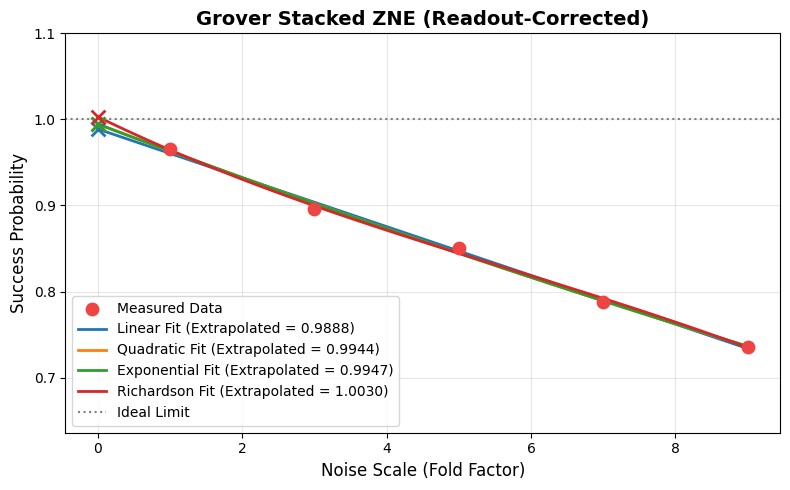

In [3]:
from quantum_mitigation.mitigation import FIT_MODELS
fit_curves_stacked = {}
for model, (func, p0) in FIT_MODELS.items():
    try:
        popt, _ = curve_fit(func, fold_factors, zne_probs_mit[:, 3], p0=p0, maxfev=10000)
        val, r2 = extrap_mit[model]
        if val is not None:
            fit_curves_stacked[model] = (val, popt, func)
    except Exception:
        pass
        
plot_zne_curves(fold_factors, zne_probs_mit[:, 3], fit_curves_stacked, title="Grover Stacked ZNE (Readout-Corrected)")
plt.show()


## 2. Stacked Mitigation on 3-Qubit QFT

We measure stacked mitigation improvements on 3-qubit QFT output state fidelity.


In [4]:
cal_matrix_3q = build_calibration_matrix(sim_noisy, 3)
unitary_qft = qft_unitary(3)

qc_ideal_qft = qft_unitary(3)
qc_ideal_qft.measure_all()
_, ideal_probs_qft = run_circuit(qc_ideal_qft, ideal_simulator())

fidelities_raw = []
fidelities_mit = []

for ff in fold_factors:
    folded = fold_circuit(unitary_qft, ff)
    folded.measure_all()
    counts, probs_raw = run_circuit(folded, sim_noisy)
    
    # Correct readout matrix
    probs_mit = apply_measurement_mitigation(counts, cal_matrix_3q)
    
    fidelities_raw.append(hellinger_fidelity(probs_raw, ideal_probs_qft))
    fidelities_mit.append(hellinger_fidelity(probs_mit, ideal_probs_qft))

# Extrapolate fidelities
extrap_fid_mit = zne_extrapolate(fold_factors, fidelities_mit)

print(f"QFT Hellinger Fidelity Extrapolations (Ideal = 1.0000):")
print(f"  Unmitigated (fold=1): Fidelity = {fidelities_raw[0]:.4f}")
print("-" * 50)
for model, (val, r2) in extrap_fid_mit.items():
    print(f"  {model:<12} ZNE Fidelity = {val:.4f}  (gap = {abs(1.0 - val):.4f})")


QFT Hellinger Fidelity Extrapolations (Ideal = 1.0000):
  Unmitigated (fold=1): Fidelity = 0.9993
--------------------------------------------------
  Linear       ZNE Fidelity = 0.9998  (gap = 0.0002)
  Quadratic    ZNE Fidelity = 0.9996  (gap = 0.0004)
  Exponential  ZNE Fidelity = 0.8280  (gap = 0.1720)
  Richardson   ZNE Fidelity = 0.9993  (gap = 0.0007)


## 3. Comparative Performance Dashboard

We visualize success probabilities on Grover's search under all scenarios: Unmitigated baseline, ZNE-only, Readout mitigation-only, and stacked.


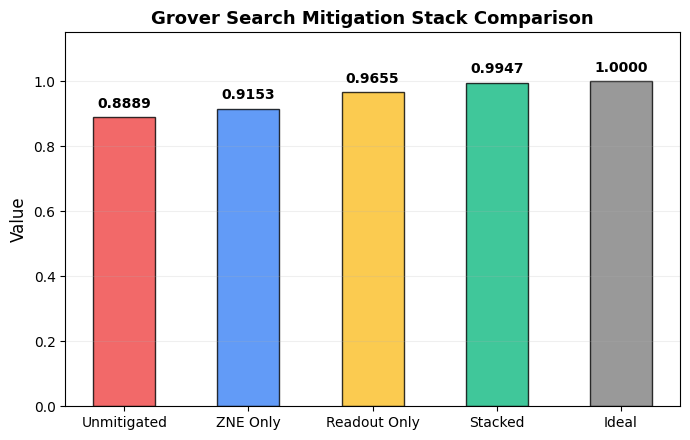

In [5]:
p_raw = zne_probs_raw[0, 3]
p_zne_only = zne_extrapolate(fold_factors, zne_probs_raw[:, 3])['Exponential'][0]
p_readout_only = zne_probs_mit[0, 3]
p_stacked = extrap_mit['Exponential'][0]

labels = ['Unmitigated', 'ZNE Only', 'Readout Only', 'Stacked', 'Ideal']
values = [p_raw, p_zne_only, p_readout_only, p_stacked, 1.0]

plot_comparison_bar(labels, values, title="Grover Search Mitigation Stack Comparison")
plt.show()
